In [1]:
%pwd
%cd /home/jovyan/work/results/Cell/
%pwd

/home/jovyan/work/results/Cell


'/home/jovyan/work/results/Cell'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
from matplotlib import rcParams
import scanpy as sc

conduct trajectory inference on NE_sc_cancer_stages_annotated data to see whether different clinical stages do have developmental hierarchy

the data is already preprocessed and scaled

In [3]:
adata = sc.read_h5ad("discrete_cancer_stages_annotated.h5ad")
adata

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'discrete_cancer_stage'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'INSS_stage_colors', '_scvi_manager_uuid', '_scvi_uuid', 'discrete_cancer_stage_colors', 'hvg', 'leiden_scVI', 'leiden_scVI_colors', 'leiden_scVI_sizes', 'neighbors', 'paga', 'sample_ID_colors', 'scrublet', 'umap'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_continuous_covs'
    layers: 'scvi_normalized'
    obsp: 'connectivities', 'distances'

Clustering and PAGA

paga already computed when re-clustering NE cells, using leiden

In [4]:
sc.tl.paga(adata, groups='discrete_cancer_stage')

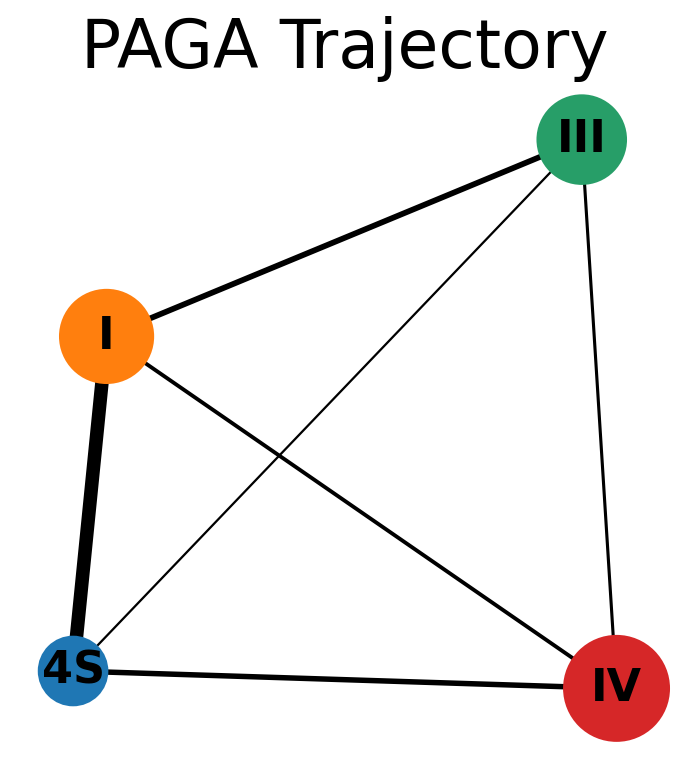

In [6]:
sc.set_figure_params(fontsize=30, figsize="5,5", frameon=False)
sc.pl.paga(adata, color='discrete_cancer_stage', node_size_scale=10, edge_width_scale=2, fontsize=20, frameon=False, title="PAGA Trajectory", threshold=0, save="_trajectory.svg")

In [7]:
adata.uns['paga']['connectivities']

<4x4 sparse matrix of type '<class 'numpy.float64'>'
	with 12 stored elements in Compressed Sparse Row format>

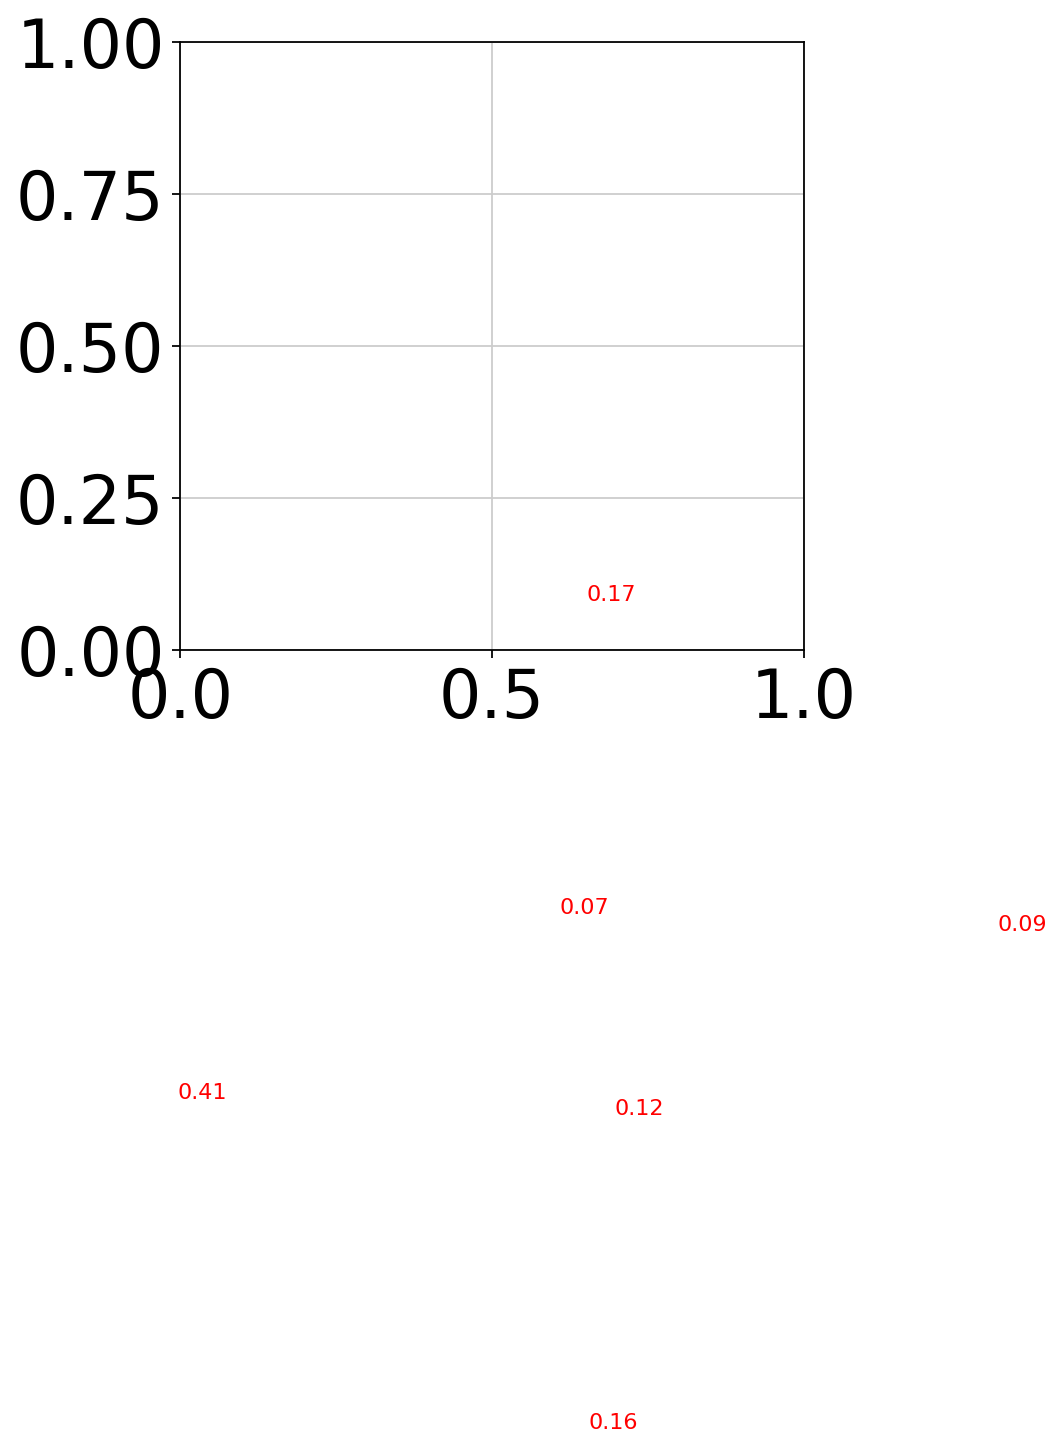

In [8]:
# Get the PAGA graph and edge weights
paga_graph = adata.uns['paga']['connectivities']
coords = adata.uns['paga']['pos']  # positions of the clusters in the plot

# Create a NetworkX graph from the PAGA connectivities matrix
G = nx.Graph(paga_graph)

# Plot edge weights
for (i, j, weight) in G.edges(data='weight'):
    # Only show the edge if it exceeds a threshold (optional)
    if weight > 0:
        x_coords = [coords[i, 0], coords[j, 0]]
        y_coords = [coords[i, 1], coords[j, 1]]
        mid_x = np.mean(x_coords)
        mid_y = np.mean(y_coords)
        plt.text(mid_x, mid_y, f'{weight:.2f}', fontsize=10, color='red', ha='center')